In [35]:
# =========================
# 1. Imports (FIXED)
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML models
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Dimensionality Reduction
from sklearn.manifold import LocallyLinearEmbedding

# Optional (for UMAP — install if needed)
import umap

In [36]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("output.csv")

# Convert BOARDINGS to numeric
df["BOARDINGS"] = pd.to_numeric(df["BOARDINGS"], errors="coerce")

df["ridership_class"] = pd.cut(
    df["BOARDINGS"],
    bins=[-1, 0, 20, df["BOARDINGS"].max()],
    labels=["No Riders", "Low", "High"]
)

print(df["ridership_class"].value_counts())

ridership_class
Low          191773
No Riders    171758
High          19183
Name: count, dtype: int64


C:\Users\balto\AppData\Local\Temp\ipykernel_7380\2745958322.py:4: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("output.csv")


In [37]:
# =========================
# Define target + features
# =========================
target = "ridership_class"

features = [
    "ROUTE_NAME",
    "ROUTE_NUMBER",
    "SERVICE_PERIOD",
    "SERVICE_CODE",
    "DIRECTION_NAME",
    "BRANCH",
    "TRIPS",
    "AVG_BOARDINGS",
    "AVG_ALIGHTINGS",
    "AVG_ACTIVITY",
    "PASS_LOAD",
    "PEAK_LOAD",
    "AVG_PEAK_LOAD",
    "CITY"
]

X = df[features]
y = df[target]

# =========================
# Identify column types
# =========================
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

In [38]:
# Remove rows where target is missing
df = df.dropna(subset=["ridership_class"])

X = df[features]
y = df["ridership_class"]

# Optional check
print(y.isna().sum())
print(y.value_counts())

0
ridership_class
Low          191773
No Riders    171758
High          19183
Name: count, dtype: int64


In [39]:
from sklearn.naive_bayes import MultinomialNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=300, solver="saga", n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost GPU": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        tree_method="hist",
        device="cuda",
        eval_metric="mlogloss",
        random_state=42
    ),
    "Naive Bayes": MultinomialNB()   # <-- NEW 4th model
}

In [40]:
# Preprocessor for most models
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Preprocessor for Naive Bayes (no scaling)
preprocessor_nb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [41]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.naive_bayes import GaussianNB

# Change model dictionary to use GaussianNB
models["Naive Bayes"] = GaussianNB()

for name, model in models.items():

    if name == "Naive Bayes":
        X_train_nb = X_train_processed
        X_test_nb = X_test_processed

        # GaussianNB needs dense arrays
        if hasattr(X_train_nb, "toarray"):
            X_train_nb = X_train_nb.toarray()

        if hasattr(X_test_nb, "toarray"):
            X_test_nb = X_test_nb.toarray()

        model.fit(X_train_nb, y_train_fast)
        y_pred = model.predict(X_test_nb)

    elif name == "XGBoost GPU":
        model.fit(X_train_processed, y_train_encoded)
        y_pred_encoded = model.predict(X_test_processed)
        y_pred = le.inverse_transform(y_pred_encoded.astype(int))

    else:
        model.fit(X_train_processed, y_train_fast)
        y_pred = model.predict(X_test_processed)

c:\Users\balto\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [42]:
# Use this if dataset is very large
sample_size = 50000

if len(X_train) > sample_size:
    X_train_fast = X_train.sample(sample_size, random_state=42)
    y_train_fast = y_train.loc[X_train_fast.index]
else:
    X_train_fast = X_train
    y_train_fast = y_train

# Columns
numeric_cols = X_train_fast.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train_fast.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

# Preprocess once
X_train_processed = preprocessor.fit_transform(X_train_fast)
X_test_processed = preprocessor.transform(X_test)

# Encode target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_fast)
y_test_encoded = le.transform(y_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=300, solver="saga", n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost GPU": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        tree_method="hist",
        device="cuda",
        eval_metric="mlogloss",
        random_state=42
    )
}

results = []

for name, model in models.items():

    if name == "XGBoost GPU":
        model.fit(X_train_processed, y_train_encoded)
        y_pred_encoded = model.predict(X_test_processed)
        y_pred = le.inverse_transform(y_pred_encoded.astype(int))
    else:
        model.fit(X_train_processed, y_train_fast)
        y_pred = model.predict(X_test_processed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

    print("\n==============================")
    print(name)
    print("==============================")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results)
print(results_df)

c:\Users\balto\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression
              precision    recall  f1-score   support

        High       0.96      0.81      0.88      3836
         Low       0.98      0.99      0.98     38355
   No Riders       0.99      1.00      0.99     34352

    accuracy                           0.98     76543
   macro avg       0.98      0.93      0.95     76543
weighted avg       0.98      0.98      0.98     76543


Random Forest
              precision    recall  f1-score   support

        High       0.99      0.15      0.26      3836
         Low       0.92      1.00      0.96     38355
   No Riders       1.00      1.00      1.00     34352

    accuracy                           0.96     76543
   macro avg       0.97      0.72      0.74     76543
weighted avg       0.96      0.96      0.94     76543


XGBoost GPU
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3836
         Low       1.00      1.00      1.00     38355
   No Riders       1.00   

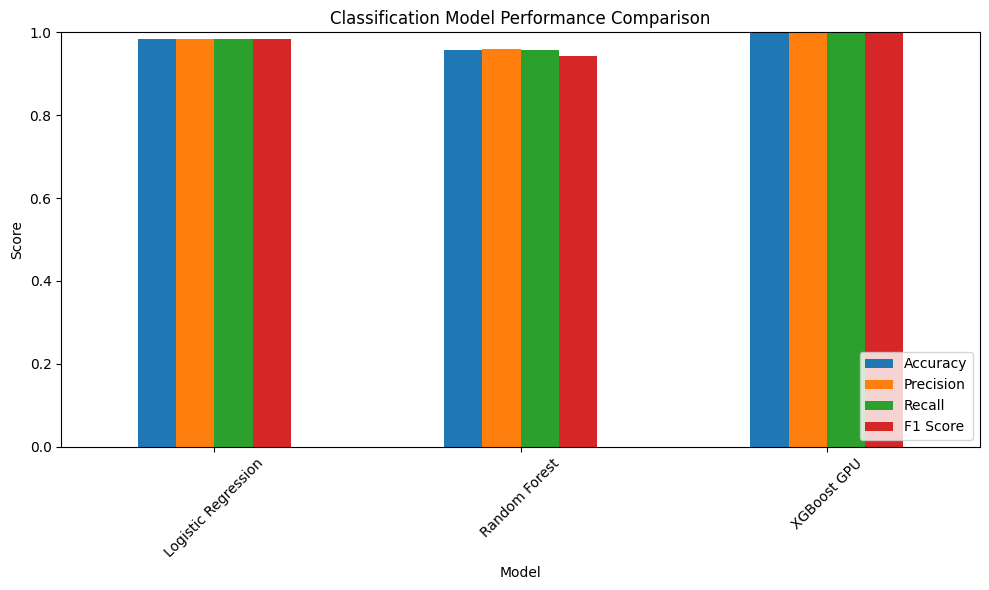

In [43]:
# =========================
# 6. Plot Model Comparison
# =========================
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(10, 6)
)

plt.title("Classification Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

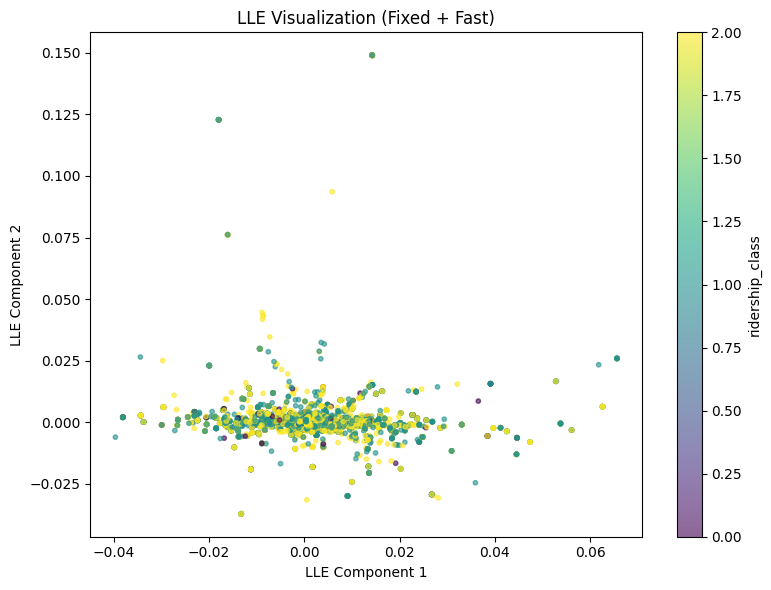

In [44]:
# Sample smaller data
sample_size = 5000

if len(X) > sample_size:
    X_sample = X.sample(sample_size, random_state=42)
    y_sample = y.loc[X_sample.index]
else:
    X_sample = X
    y_sample = y

# Preprocess
X_sample_processed = preprocessor.fit_transform(X_sample)

# Convert to dense safely
if hasattr(X_sample_processed, "toarray"):
    X_sample_processed = X_sample_processed.toarray()

# Remove duplicate rows (VERY IMPORTANT)
X_sample_processed = np.unique(X_sample_processed, axis=0)

# Encode labels
label_encoder = LabelEncoder()
y_sample_encoded = label_encoder.fit_transform(y_sample[:len(X_sample_processed)])

# FIX: use dense solver + regularization
lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=5,
    eigen_solver="dense",   # <-- KEY FIX
    reg=1e-3,               # <-- stabilizes matrix
    random_state=42
)

X_lle = lle.fit_transform(X_sample_processed)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_lle[:, 0],
    X_lle[:, 1],
    c=y_sample_encoded,
    cmap="viridis",
    alpha=0.6,
    s=10
)

plt.colorbar(label=target)
plt.title("LLE Visualization (Fixed + Fast)")
plt.xlabel("LLE Component 1")
plt.ylabel("LLE Component 2")
plt.tight_layout()
plt.show()

c:\Users\balto\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


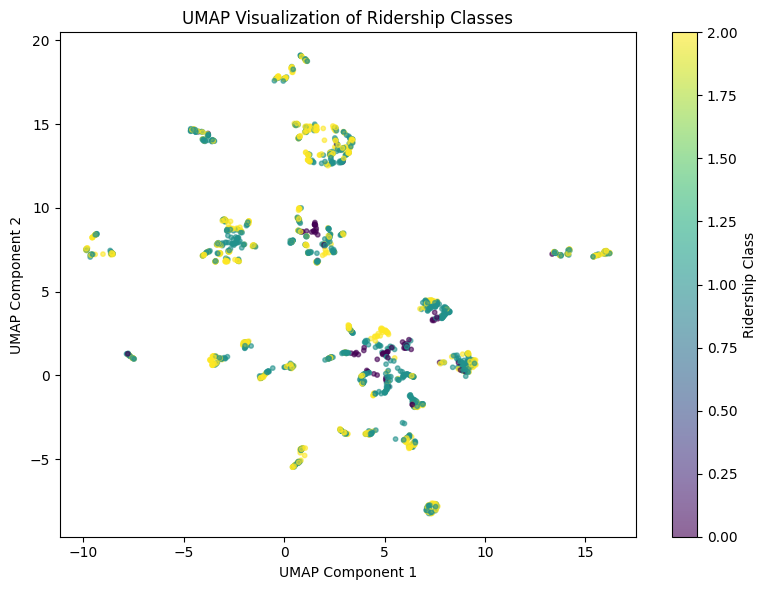

In [45]:
# =========================
# 8. UMAP Visualization - FIXED
# =========================

# Sample for speed
sample_size = 2000

if len(X) > sample_size:
    X_sample = X.sample(sample_size, random_state=42)
    y_sample = y.loc[X_sample.index]
else:
    X_sample = X
    y_sample = y

# Create X_processed
X_processed = preprocessor.fit_transform(X_sample)

# Convert sparse matrix to dense
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

# Convert labels to numbers for color plotting
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_sample)

# Run UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_processed)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y_encoded,
    cmap="viridis",
    alpha=0.6,
    s=10
)

plt.colorbar(scatter, label="Ridership Class")
plt.title("UMAP Visualization of Ridership Classes")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.tight_layout()
plt.show()